# ROC Curve and AUC Comparison

This notebook compares the classification performance of the previously trained ResNet50, VGG16, and DenseNet121 models on the BUSI testing set. The models will not be retrained; their saved trained weights will be loaded and predicted probabilities will be used to calculate ROC curves and AUC values. All three ROC curves will be plotted together for comparison using the same BUSI testing set and preprocessing settings from the completed classification notebooks for a fair comparison.

## Imports and Environment Setup

This section imports the libraries needed to load the BUSI test data, recreate the three model architectures, load their saved weights, generate predicted probabilities, calculate ROC curves and AUC values, and plot the comparison figure. The same random seed and device setup from the completed classification notebooks is reused for consistency.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# Reproducible environment matching the classification notebooks
SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


## BUSI Testing Dataset

This section reuses the exact same BUSI testing set, dataset class, preprocessing transforms, label mapping, and DataLoader settings from the completed classification notebooks so that all three trained models are evaluated on the same data.

In [2]:
# BUSI dataset paths and test split settings from the classification notebooks
dataset_dir = Path("/data/barbanp/datasets/BUSI")
image_folder = dataset_dir / "images-20260621T231610Z-3-001" / "images"
test_path = dataset_dir / "test.xlsx"

label_names = {1: "benign", 0: "malignant"}
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

class BUSIDataset(Dataset):
    """PyTorch dataset for BUSI image filenames and binary labels."""

    def __init__(self, dataframe, image_folder, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_folder = Path(image_folder)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.image_folder / str(row['Image'])

        if not image_path.is_file():
            raise FileNotFoundError(f'Image file not found: {image_path}')

        with Image.open(image_path) as image:
            image = image.convert('RGB')
            if self.transform is not None:
                image = self.transform(image)

        label = torch.tensor(int(row['Label']), dtype=torch.long)
        return image, label

# Reuse the same preprocessing transforms used for ImageNet-based transfer learning.
image_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load only the predefined BUSI test split and create the test dataset/loader.
test_df = pd.read_excel(test_path)
test_dataset = BUSIDataset(
    dataframe=test_df,
    image_folder=image_folder,
    transform=image_transforms
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


## Load Trained Models

This section recreates the ResNet50, VGG16, and DenseNet121 architectures exactly as they were configured in the completed classification notebooks, then loads their previously saved trained weights. The models are loaded for evaluation only and will not be retrained.

In [3]:
# Recreate each architecture with a two-class output layer, then load trained weights.
resnet50_model = models.resnet50(weights=None)
num_features = resnet50_model.fc.in_features
resnet50_model.fc = nn.Linear(num_features, 2)
resnet50_model.load_state_dict(torch.load(
    "/data/barbanp/research_training/models/resnet50_busi.pth",
    map_location=device,
    weights_only=True
))
resnet50_model = resnet50_model.to(device)
resnet50_model.eval()

vgg16_model = models.vgg16(weights=None)
num_features = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_features, 2)
vgg16_model.load_state_dict(torch.load(
    "/data/barbanp/research_training/models/vgg16_busi.pth",
    map_location=device,
    weights_only=True
))
vgg16_model = vgg16_model.to(device)
vgg16_model.eval()

densenet121_model = models.densenet121(weights=None)
num_features = densenet121_model.classifier.in_features
densenet121_model.classifier = nn.Linear(num_features, 2)
densenet121_model.load_state_dict(torch.load(
    "/data/barbanp/research_training/models/densenet121_busi.pth",
    map_location=device,
    weights_only=True
))
densenet121_model = densenet121_model.to(device)
densenet121_model.eval()

print("Loaded trained ResNet50, VGG16, and DenseNet121 models for evaluation.")


/data/barbanp/miniconda3/envs/myenv/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Loaded trained ResNet50, VGG16, and DenseNet121 models for evaluation.


## Collect Predicted Probabilities

ROC curves require prediction scores or probabilities rather than final predicted class labels. Each trained model will evaluate the same BUSI testing images, and the predicted probability for the malignant class will be collected.

The existing BUSI label mapping is: 0 = malignant, 1 = benign. Therefore, malignant is the positive class for this ROC analysis, and the probability for class index 0 must be collected.

In [4]:
# Collect malignant class probabilities for each model and true labels
true_labels = []
resnet50_probabilities = []
vgg16_probabilities = []
densenet121_probabilities = []

softmax = torch.nn.Softmax(dim=1)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        resnet_outputs = resnet50_model(images)
        vgg16_outputs = vgg16_model(images)
        densenet121_outputs = densenet121_model(images)

        resnet_probs = softmax(resnet_outputs)[:, 0]  # malignant probability
        vgg16_probs = softmax(vgg16_outputs)[:, 0]  # malignant probability
        densenet121_probs = softmax(densenet121_outputs)[:, 0]  # malignant probability

        true_labels.extend(labels.cpu().numpy())
        resnet50_probabilities.extend(resnet_probs.cpu().numpy())
        vgg16_probabilities.extend(vgg16_probs.cpu().numpy())
        densenet121_probabilities.extend(densenet121_probs.cpu().numpy())

true_labels = np.array(true_labels)
resnet50_probabilities = np.array(resnet50_probabilities)
vgg16_probabilities = np.array(vgg16_probabilities)
densenet121_probabilities = np.array(densenet121_probabilities)

print(f"True labels: {len(true_labels)}")
print(f"ResNet50 probabilities: {len(resnet50_probabilities)}")
print(f"VGG16 probabilities: {len(vgg16_probabilities)}")
print(f"DenseNet121 probabilities: {len(densenet121_probabilities)}")


True labels: 130
ResNet50 probabilities: 130
VGG16 probabilities: 130
DenseNet121 probabilities: 130


## Calculate ROC Curves and AUC Values

The ROC curve compares the true positive rate and false positive rate across many classification thresholds. Malignant is the positive class in this analysis, and the BUSI label mapping is: 0 = malignant, 1 = benign. Therefore, the ROC calculation must explicitly use `pos_label=0`.

The AUC value summarizes the ROC curve into a single number, with a higher AUC indicating better separation between malignant and benign cases.

In [5]:
# Calculate ROC curves and AUC values for each model
resnet50_fpr, resnet50_tpr, resnet50_thresholds = roc_curve(
    true_labels, resnet50_probabilities, pos_label=0
)
resnet50_auc = auc(resnet50_fpr, resnet50_tpr)

vgg16_fpr, vgg16_tpr, vgg16_thresholds = roc_curve(
    true_labels, vgg16_probabilities, pos_label=0
)
vgg16_auc = auc(vgg16_fpr, vgg16_tpr)

densenet121_fpr, densenet121_tpr, densenet121_thresholds = roc_curve(
    true_labels, densenet121_probabilities, pos_label=0
)
densenet121_auc = auc(densenet121_fpr, densenet121_tpr)

print(f"ResNet50 AUC: {resnet50_auc:.4f}")
print(f"VGG16 AUC: {vgg16_auc:.4f}")
print(f"DenseNet121 AUC: {densenet121_auc:.4f}")


ResNet50 AUC: 0.8966
VGG16 AUC: 0.8986
DenseNet121 AUC: 0.9259


## ROC Curve Comparison

This figure plots the ROC curves of ResNet50, VGG16, and DenseNet121 together so their ability to distinguish malignant from benign BUSI images can be visually compared across classification thresholds.

The x-axis is the false positive rate and the y-axis is the true positive rate. Curves closer to the top-left generally indicate better classification performance. Each model's AUC value will be shown in the legend, and the diagonal line represents random-classifier performance with an AUC of approximately 0.5.

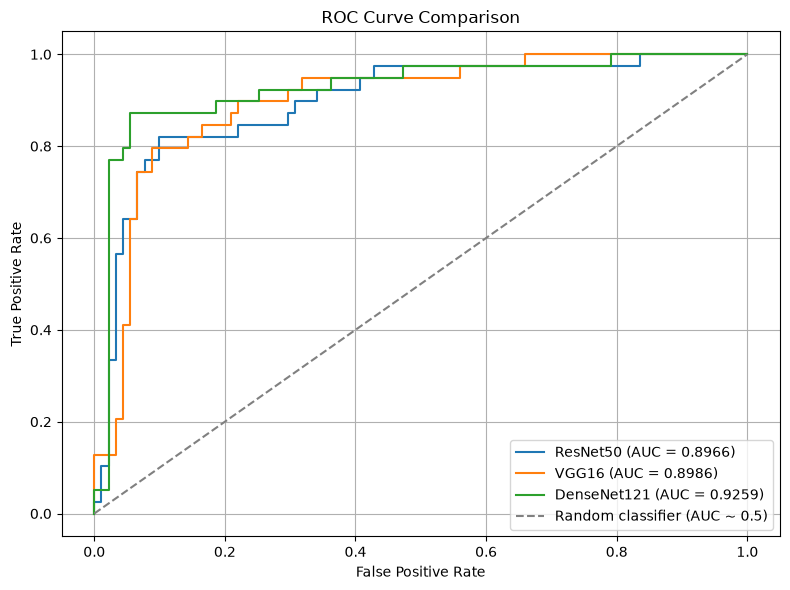

In [6]:
# Plot ROC curves for the three trained models
plt.figure(figsize=(8, 6))
plt.plot(resnet50_fpr, resnet50_tpr, label=f"ResNet50 (AUC = {resnet50_auc:.4f})")
plt.plot(vgg16_fpr, vgg16_tpr, label=f"VGG16 (AUC = {vgg16_auc:.4f})")
plt.plot(densenet121_fpr, densenet121_tpr, label=f"DenseNet121 (AUC = {densenet121_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier (AUC ~ 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


## Findings and Conclusion

All three ROC curves lie well above the random-classifier diagonal, showing that these trained models distinguish malignant from benign BUSI images better than random classification. DenseNet121 achieved the highest AUC of 0.9259 and showed the strongest overall ability among the three models to separate malignant from benign cases across thresholds. ResNet50 and VGG16 had AUCs of 0.8966 and 0.8986, respectively, and their AUC values were very similar; the 0.0020 difference is not evidence that VGG16 is meaningfully better. The curves cross in some regions, so the relative true-positive/false-positive tradeoff can vary depending on the classification threshold. Overall, DenseNet121 had the best ROC/AUC performance among these three trained models on this BUSI testing set.